# MM Kinetic Analysis

In [1]:
import pandas as pd
import math
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from scipy.optimize import curve_fit
import matplotlib.cm as cm


## MM Functions

In [2]:
class KineticDataException(Exception):
    pass

In [3]:
def divide_chunks(l, n):
    n = math.ceil(len(l) / float(n))
    for i in range(0, len(l), n):
        yield l[i:i + n]

In [4]:
def compute_initial_reaction_slope(time_arr: np.array, 
                                   signal_arr: np.array,
                                  min_included_percent: int = 5): 
    """
    Determines best linear fit to initial slope of data, by fitting regressions to 
    all percentiles of the data--greater than some defined minimum--anchored at the origin.
    
    Args:
        time_arr (np.array): array of assay read times
        signal_arr (np.array): array of kinetic signal readouts
        min_included_percent (int) = 5: minimum percent of data to be included 
    
    Returns:
        slope, intercept, score ((float, float, float)): fit parameters of best fit
        
    """
    # Need to triage further for different definitions of minimum
    MIN_INCLUDED_DATA_POINTS = 5
    
    perc_concs = list(divide_chunks(signal_arr, 100))
    perc_times = list(divide_chunks(time_arr, 100))
 
    scores = []
    slopes = [] 
    intercepts = []
    
    min_inclusion = max(len(perc_times) * min_included_percent // 100, 5)
    
    for i in range(len(perc_times), min_inclusion, -1):
        curr_times = np.concatenate(perc_times[:i])
        curr_concs = np.concatenate(perc_concs[:i])
        #curr_times = [item for sublist in perc_times[:i] for item in sublist]
        #curr_concs = [item for sublist in perc_concs[:i] for item in sublist]
        
        reg = LinearRegression().fit(np.array(curr_times).reshape(-1,1), curr_concs)
        curr_score = reg.score(np.array(curr_times).reshape(-1,1), curr_concs)
        scores.append(curr_score)
        slopes.append(reg.coef_)
        intercepts.append(reg.intercept_)
    
    if len(scores) == 0 and min_included_percent == 100:
        reg = LinearRegression().fit(np.array(perc_times).reshape(-1,1), perc_concs)
        curr_score = reg.score(np.array(perc_times).reshape(-1,1), perc_concs)
        return reg.coef_.item(), reg.intercept_.item(), curr_score
    
    max_r2_idx = np.argmax(scores)
    
    if scores[max_r2_idx] < 0.9:
        return np.array([np.nan]), np.array([np.nan]), np.array([np.nan])
        #return float('nan'), float('nan'), float('nan')
    return slopes[max_r2_idx], intercepts[max_r2_idx], scores[max_r2_idx]


In [5]:
def get_initial_slopes(time_arr: np.array, kinetic_data: np.array, plot: bool = False,
                       substrate_concs: [int] = None, 
                       title: str = None, fig_size: (int, int) = (10,10), triage: bool = False):
    
    if plot and (substrate_concs is None or title is None):
        raise KineticDataException("Plotting initial slopes requires substratce concentration and titles")
    
    slopes = []
    intercepts = []
    scores = []
    
    for data in kinetic_data:
        slope, intercept, score = compute_initial_reaction_slope(time_arr, data)
        slopes.append(slope)
        intercepts.append(intercept)
        scores.append(score)
        
    if plot:
       
        fig = plt.figure(figsize=fig_size) 
        
        for data in kinetic_data:
            plt.scatter(time_arr, data)
        x = np.linspace(min(time_arr), max(time_arr), 1000)
       
        x_tiled = np.tile(x,(len(substrate_concs),1)).T
        plt.plot(x_tiled,
                 x_tiled * np.array(slopes).T + np.array(intercepts).T,
                 linewidth=3, label=[f"{sub_conc:.2f} µM" for sub_conc in substrate_concs])
        plt.title(title)
        plt.xlabel("Time (seconds)")
        plt.ylabel("µM")
        plt.legend() 
    
        if triage:

            fig, axs = plt.subplots(math.ceil(len(sub_concs) / 2), 2, figsize=(15,15))

            for ax, data, slope, intercept, sub_conc in zip(axs.flat, kinetic_data, slopes, intercepts, substrate_concs):
                ax.scatter(time_arr, data)
                ax.set_title(f"{sub_conc:.2f} µM")
                ax.plot(x, x * slope + intercept)
           
    return np.concatenate(slopes)

In [6]:
def mm_model(x, v_max, Km):
    return v_max * x / (x + Km)

In [26]:
def fit_and_plot_micheaelis_menten(rep_1_slopes: np.array, rep_2_slopes: np.array, sub_concs: [int], e_conc: float, title: str, background_rates: np.array = None):
    avg_slopes = np.nanmean([rep_1_slopes, rep_2_slopes], axis=0)[..., np.newaxis]
   
    if background_rates is not None:
        avg_slopes -= background_rates
    errs = np.nanstd([rep_1_slopes, rep_2_slopes], axis=0) 
    params, _ = curve_fit(mm_model, sub_concs, np.concatenate(avg_slopes))
    
    plt.figure(figsize=(10,6))

    plt.scatter(sub_concs, avg_slopes/e_conc)
    plt.errorbar(sub_concs, np.concatenate(avg_slopes/e_conc), yerr=(errs/e_conc).T, fmt="o", capsize=5)
    x = np.linspace(0, 50, 50)
    plt.plot(x, mm_model(x, params[0], params[1]) / e_conc)
    plt.xlabel("[S] (mM)")
    plt.ylabel("v ($s^{-1}$)")
    plt.title(title + " kinetics: $k_{cat}$ = " +f"{params[0] / e_conc:.0f}" + " $s^{-1}$ " + f"  $K_m$ = {params[1]:.0f} mM")

# Data Cleaning and Prep

In [8]:
df = pd.read_csv("../data/nh_adh_mm_20220718.csv", header=0)

In [9]:
df.head()

,Time,No Enzyme,20mM,10mM,5mM,2.5mM,1.25mM,0.625mM,Unnamed: 8,Unnamed: 9,...,Unnamed: 22,Unnamed: 23,Unnamed: 24,Unnamed: 25,Unnamed: 26,Unnamed: 27,Unnamed: 28,Unnamed: 29,Unnamed: 30,Unnamed: 31
0,0,99,772,702,431,206,346,155,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,15,90,790,700,462,222,360,171,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,30,97,855,729,482,210,385,183,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,45,92,908,764,505,251,371,181,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,60,96,982,802,550,268,405,196,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [10]:
time_arr = np.array(df["Time"])

In [11]:
time_arr.shape

(402,)

The shape of the time array indicates our expected number of signal readings ^ so the second dimension of all our subsequent arrays should match this.

# Computing Background Rates

In [30]:
RFU_TO_NADH_CONVERSION_FACTOR = 86000

In this case, the wells are indicated by columns, and I am looking for wells [J1:J16]

I did my replicates next to each other along the row, so J1==J2, J3==J4 etc.,
so now I need to separate by replicates.

In [15]:
sub_concs = [20, 10, 5, 2.5, 1.25, 0.625]

# gsADK I111L Data

In [16]:
adh_df = df.iloc[:, 2:8]
adh_df
adh_arr = np.array(adh_df).T / RFU_TO_NADH_CONVERSION_FACTOR # convert to uM NADPH

In [18]:
adh_arr.shape

(6, 402)

In [28]:
adh_conc = 14.8 * 1e-6 # nM

In [29]:
adh_conc

1.48e-05

## Scatter Plot Data

Text(0, 0.5, '[NADH] (mM)')

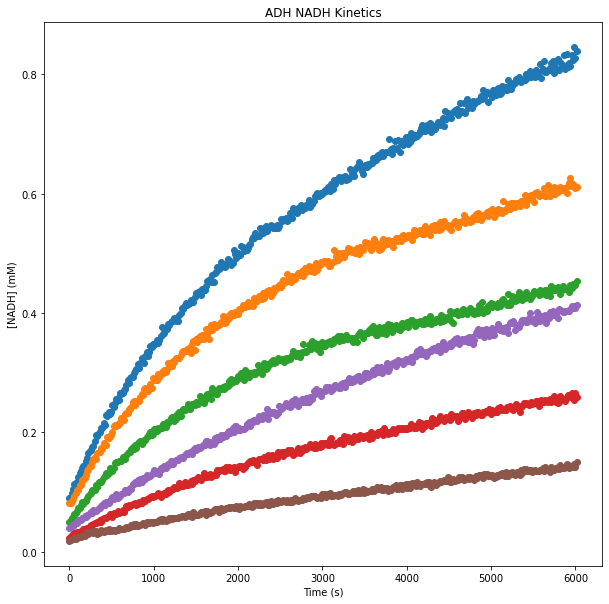

In [20]:
fig = plt.figure(figsize=(10,10))

for data in adh_arr:
    plt.scatter(time_arr, data)
plt.title("ADH NADH Kinetics")
plt.xlabel("Time (s)")
plt.ylabel("[NADH] (mM)")

TODO: add some triage functionality to show poor fit on rep 1

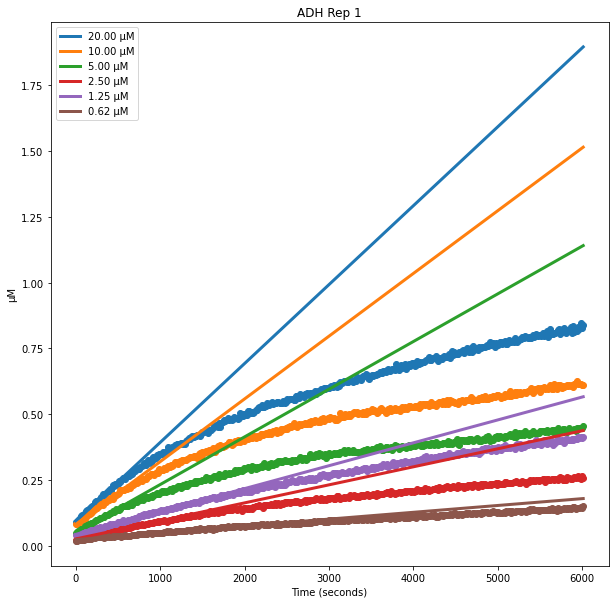

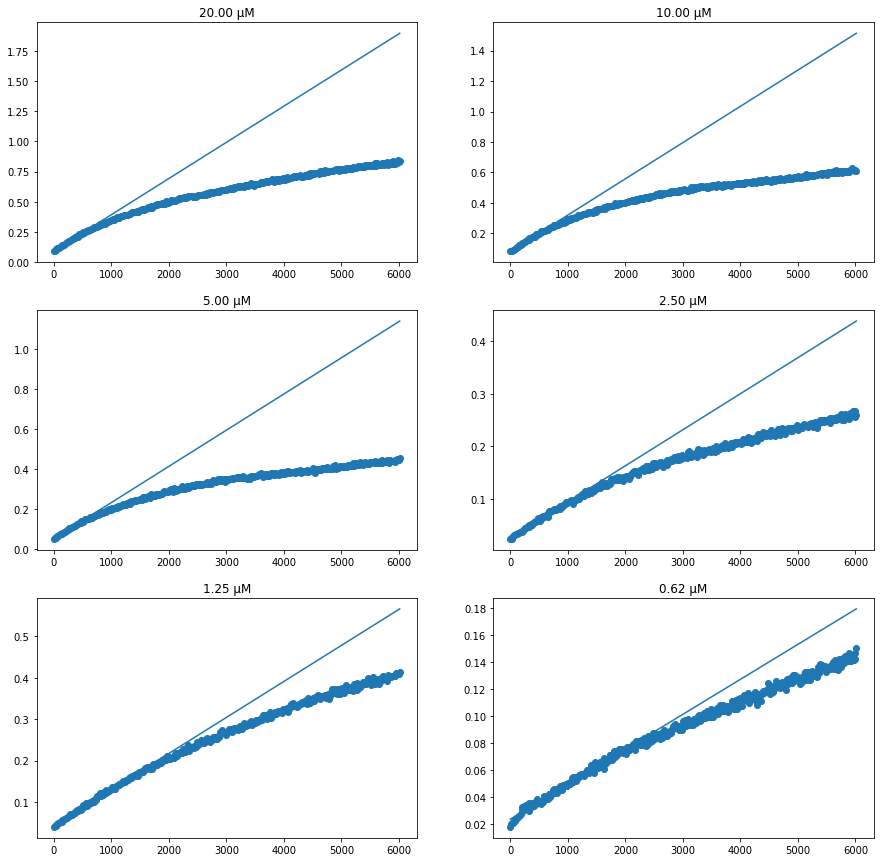

In [21]:
#gsADK_i111l_r1_slopes = get_initial_slopes(time_arr, gs_i111l_rep_1_arr)
adh_initial_slopes = get_initial_slopes(time_arr, adh_arr, 
                                           plot=True, substrate_concs=sub_concs,
                                           title="ADH Rep 1", triage=True)

In [22]:
adh_initial_slopes

array([2.99441947e-04, 2.38097212e-04, 1.80917643e-04, 6.84187362e-05,
       8.68652503e-05, 2.59014804e-05])

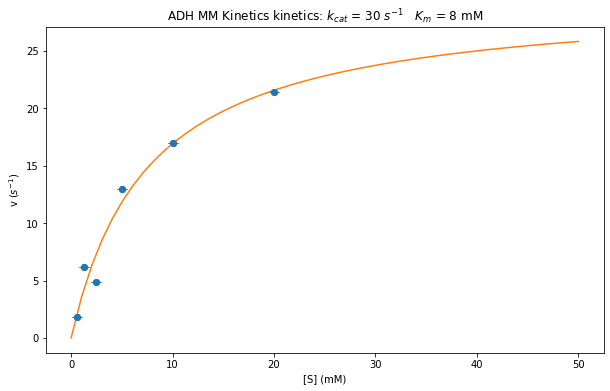

In [27]:
fit_and_plot_micheaelis_menten(np.array(adh_initial_slopes), np.array(adh_initial_slopes), sub_concs, 
                               adh_conc, "ADH MM Kinetics")

Cut off initial rxn data when flat/artifcact